# Analyse des Trajectoires TLS → ORY
## Étude comparative par périodes : Nominal (2019) | COVID-19 (2020) | Guerre en Ukraine (2022)

Ce notebook analyse les données ADS-B historiques issues de l'OpenSky Network pour trois périodes
représentatives de régimes opérationnels distincts, en se concentrant sur les vols Toulouse-Blagnac
(TLS/LFBO) → Paris Orly (ORY/LFPO).

---


## 1. Imports

In [2]:
import glob
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from traffic.core import Traffic, Flight
from traffic.data import airports

import re
from datetime import timedelta, date
import polars as pl

warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


---

## 2. Configuration

In [ ]:
DATA_ROOT = Path("./data")
PERIODS = {
    "2019 (Nominal)":  "2019-02-25",
    "2020 (COVID-19)": "2020-04-06",
    "2022 (Ukraine)":  "2022-02-28",
}
PERIOD_DAYS = 90

ORIGIN_ICAO = "LFBO" 
DEST_ICAO   = "LFPO" 
ORIGIN_IATA = "TLS"
DEST_IATA   = "ORY"
AIRPORT_RADIUS_DEG = 0.15
LAT_MIN, LAT_MAX = 43.0, 49.5 
LON_MIN, LON_MAX = -0.5, 3.5 
MIN_FLIGHT_DURATION_MIN = 30  
MAX_FLIGHT_DURATION_MIN = 150
MIN_POINTS              = 20  
LOW_ALT_THRESHOLD_FT = 3_000
COLORS = {
    "2019 (Nominal)":  "#2196F3",
    "2020 (COVID-19)": "#F44336",
    "2022 (Ukraine)":  "#FF9800",
}
print("Configuration OK")


Configuration OK


---

## 3. Chargement des données

In [ ]:
def convert_csv_to_parquet():
    csv_files = list(DATA_ROOT.glob("data_*.csv"))
    print(f"Conversion de {len(csv_files)} fichiers CSV en Parquet...")
    for csv_path in csv_files:
        parquet_path = csv_path.with_suffix(".parquet")
        if parquet_path.exists():
            continue
        try:
            df = pl.read_csv(csv_path, low_memory=True)
            df.write_parquet(parquet_path, compression="zstd")
            print(f"Converti : {csv_path.name} -> {parquet_path.name}")
        except Exception as e:
            print(f"Erreur sur {csv_path.name} : {e}")

convert_csv_to_parquet()

Conversion de 0 fichiers CSV en Parquet...


In [ ]:
DTYPES = {
    "icao24":       str,
    "callsign":     str,
    "squawk":       str,
    "time":         "int64",
    "lat":          "float64",
    "lon":          "float64",
    "velocity":     "float64",
    "heading":      "float64",
    "vertrate":     "float64",
    "baroaltitude": "float64",
    "geoaltitude":  "float64",
    "onground":     "boolean",
}

def load_single_parquet_lazy(file_path: str) -> pl.LazyFrame:
    return (
        pl.scan_parquet(file_path)
        .rename({
            "time": "timestamp",
            "lat": "latitude",
            "lon": "longitude",
            "velocity": "groundspeed",
            "heading": "track",
            "vertrate": "vertical_rate",
            "baroaltitude": "altitude",
        })
        .filter((pl.col("latitude") >= LAT_MIN - 1.0) & (pl.col("latitude") <= LAT_MAX + 0.5) & (pl.col("longitude") >= LON_MIN - 0.5) & (pl.col("longitude") <= LON_MAX + 0.5))
        .drop_nulls(subset=["latitude", "longitude"])
    )


def get_period_dates(start_date_str: str, n_days: int = PERIOD_DAYS) -> list[str]:
    start = date.fromisoformat(start_date_str)
    return [(start + timedelta(days=i)).isoformat() for i in range(n_days)]


def load_period_as_traffic(start_date_str: str, data_root: Path, n_days: int = PERIOD_DAYS) -> Traffic:
    period_dates = set(get_period_dates(start_date_str, n_days))
    date_pattern = re.compile(r"data_(\d{4}-\d{2}-\d{2})-\d{2}\.parquet$")
    all_parquet = sorted(data_root.glob("data_*.parquet"))
    parquet_files = [str(p) for p in all_parquet if (m := date_pattern.search(p.name)) and m.group(1) in period_dates]
    if not parquet_files:
        return Traffic(pd.DataFrame())
    lazy_dfs = []
    for f in parquet_files:
        try:
            lazy_dfs.append(load_single_parquet_lazy(f))
        except Exception as e:
            print(f"Erreur préparation {f}: {e}")

    if not lazy_dfs:
        return Traffic(pd.DataFrame())
    combined_lazy = pl.concat(lazy_dfs)
    combined_lazy = combined_lazy.with_columns([
        (pl.col("groundspeed") * 1.94384) if "groundspeed" in combined_lazy.columns else pl.col("groundspeed"),
        (pl.col("altitude") * 3.28084) if "altitude" in combined_lazy.columns else pl.col("altitude"),
        (pl.col("geoaltitude") * 3.28084) if "geoaltitude" in combined_lazy.columns else pl.col("geoaltitude"),
        (pl.col("vertical_rate") * 196.85) if "vertical_rate" in combined_lazy.columns else pl.col("vertical_rate"),
        pl.from_epoch("timestamp", time_unit="s").dt.replace_time_zone("UTC"),
        pl.col("callsign").str.strip_chars() if "callsign" in combined_lazy.columns else pl.col("callsign")
    ])

    print(f"► Exécution des filtres et chargement en mémoire pour {start_date_str}...")
    raw_pl = combined_lazy.collect()
    print(f"  {start_date_str} : {len(raw_pl):,} points ADS-B chargés en mémoire.")
    return Traffic(raw_pl.to_pandas())

print("Chargement des données brutes...\n")
traffic_days: dict[str, Traffic] = {}
for label, start_date in PERIODS.items():
    print(f"► {label}")
    traffic_days[label] = load_period_as_traffic(start_date, DATA_ROOT)
    print()
print("Chargement terminé.")


Chargement des données brutes...

► 2019 (Nominal)
► Exécution des filtres et chargement en mémoire pour 2019-02-25...
  2019-02-25 : 8,508,801 points ADS-B chargés en mémoire.

► 2020 (COVID-19)
► Exécution des filtres et chargement en mémoire pour 2020-04-06...
  2020-04-06 : 886,355 points ADS-B chargés en mémoire.

► 2022 (Ukraine)
► Exécution des filtres et chargement en mémoire pour 2022-02-28...
  2022-02-28 : 8,933,799 points ADS-B chargés en mémoire.

Chargement terminé.


---

## 4. Extraction des vols TLS → ORY

In [ ]:
tls_airport = airports[ORIGIN_ICAO]
ory_airport = airports[DEST_ICAO]
print(f"Départ  : {tls_airport.name} ({tls_airport.icao}) "
      f"— {tls_airport.latitude:.4f}°N, {tls_airport.longitude:.4f}°E")
print(f"Arrivée : {ory_airport.name} ({ory_airport.icao}) "
      f"— {ory_airport.latitude:.4f}°N, {ory_airport.longitude:.4f}°E")

Départ  : Toulouse-Blagnac Airport (LFBO) — 43.6291°N, 1.3638°E
Arrivée : Paris-Orly Airport (LFPO) — 48.7295°N, 2.3590°E


In [ ]:
def bbox_mask(df: pd.DataFrame, apt_lat: float, apt_lon: float,
              radius: float = AIRPORT_RADIUS_DEG) -> pd.Series:
    return ((df["latitude"].sub(apt_lat).abs()  < radius) & (df["longitude"].sub(apt_lon).abs() < radius))

def ground_mask(df: pd.DataFrame) -> pd.Series:
    if "onground" in df.columns:
        on_g = df["onground"].fillna(False).astype(bool)
        if on_g.any():
            return on_g
    if "altitude" in df.columns: 
        return df["altitude"].fillna(0) < LOW_ALT_THRESHOLD_FT
    return pd.Series(False, index=df.index)

def find_tls_departure_time(df: pd.DataFrame) -> pd.Timestamp | None:
    """Cherche le moment de décollage depuis TLS."""
    mask = bbox_mask(df, tls_airport.latitude, tls_airport.longitude) & ground_mask(df)
    candidates = df.loc[mask, "timestamp"]
    if candidates.empty:
        return None
    return candidates.max()

def find_ory_arrival_time(df: pd.DataFrame) -> pd.Timestamp | None:
    """Cherche le moment d'atterrissage à ORY (Modifié)."""
    mask = bbox_mask(df, ory_airport.latitude, ory_airport.longitude) & ground_mask(df)
    candidates = df.loc[mask, "timestamp"]
    if candidates.empty:
        return None
    return candidates.min()

def clip_and_validate(df_sorted: pd.DataFrame) -> Flight | None:
    t_dep = find_tls_departure_time(df_sorted)
    if t_dep is None:
        return None
    t_arr = find_ory_arrival_time(df_sorted) # Modifié
    if t_arr is None:
        return None
    if t_dep >= t_arr:
        return None

    duration_min = (t_arr - t_dep).total_seconds() / 60
    if not (MIN_FLIGHT_DURATION_MIN <= duration_min <= MAX_FLIGHT_DURATION_MIN):
        return None
    df_flight = df_sorted[(df_sorted["timestamp"] >= t_dep) & (df_sorted["timestamp"] <= t_arr)].copy()

    if "onground" in df_flight.columns:
        df_flight = df_flight[~df_flight["onground"].fillna(False).astype(bool)]
    elif "altitude" in df_flight.columns:
        df_flight = df_flight[df_flight["altitude"] >= LOW_ALT_THRESHOLD_FT]

    if len(df_flight) < MIN_POINTS:
        return None
    return Flight(df_flight.reset_index(drop=True))


def extract_tls_ory_flights(t: Traffic, label: str) -> list[Flight]:
    if t is None or t.data.empty:
        return []
    data = t.data
    icao24_near_tls = set(data.loc[bbox_mask(data, tls_airport.latitude, tls_airport.longitude), "icao24"])
    icao24_near_ory = set(data.loc[bbox_mask(data, ory_airport.latitude, ory_airport.longitude), "icao24"]) # Modifié
    candidates = icao24_near_tls & icao24_near_ory # Modifié

    print(f"  {label} : {len(candidates)} icao24 candidat(s)")
    if not candidates:
        return []
    t_candidates = Traffic(data[data["icao24"].isin(candidates)].copy())
    valid_flights: list[Flight] = []
    n_segments = 0

    for flight in t_candidates:
        for segment in flight.split("10 min"):
            n_segments += 1
            df_seg = segment.data.sort_values("timestamp").reset_index(drop=True)

            result = clip_and_validate(df_seg)
            if result is not None:
                valid_flights.append(result)

    print(f"  {label} : {len(valid_flights)} vol(s) TLS→ORY validé(s) sur {n_segments} segment(s) analysé(s)") # Modifié
    return valid_flights


print("Extraction des vols TLS → ORY...\\n")
flights_by_day: dict[str, list[Flight]] = {}
for label, t in traffic_days.items():
    print(f"► {label}")
    flights_by_day[label] = extract_tls_ory_flights(t, label) # Modifié
    print()
print("Extraction terminée.")

Extraction des vols TLS → ORY...\n
► 2019 (Nominal)
  2019 (Nominal) : 1065 icao24 candidat(s)
  2019 (Nominal) : 66 vol(s) TLS→ORY validé(s) sur 17619 segment(s) analysé(s)

► 2020 (COVID-19)
  2020 (COVID-19) : 40 icao24 candidat(s)
  2020 (COVID-19) : 1 vol(s) TLS→ORY validé(s) sur 278 segment(s) analysé(s)

► 2022 (Ukraine)
  2022 (Ukraine) : 910 icao24 candidat(s)
  2022 (Ukraine) : 151 vol(s) TLS→ORY validé(s) sur 14444 segment(s) analysé(s)

Extraction terminée.


---

## 5. Résumé rapide

In [ ]:
print(f"{'Période':<22} {'Vols':>6} {'Durée moy (min)':>16} {'Alt max moy (FL)':>17} {'Points moy':>11}")
print("-" * 75)

for label, flights in flights_by_day.items():
    if not flights:
        print(f"{label:<22} {'0':>6}")
        continue
    durations, alt_maxs, n_points = [], [], []
    for f in flights:
        df = f.data.sort_values("timestamp")
        dur = (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds() / 60
        durations.append(dur)
        if "altitude" in df.columns:
            alt_maxs.append(df["altitude"].max() / 100)
        n_points.append(len(df))
    print(
        f"{label:<22} {len(flights):>6} "
        f"{np.mean(durations):>15.1f} "
        f"{np.mean(alt_maxs) if alt_maxs else 0:>16.0f} "
        f"{np.mean(n_points):>10.0f}"
    )

Période                  Vols  Durée moy (min)  Alt max moy (FL)  Points moy
---------------------------------------------------------------------------
2019 (Nominal)             66            64.1              334        385
2020 (COVID-19)             1            78.7              180        471
2022 (Ukraine)            151            59.2              318        355


---

## 6. Carte des trajectoires TLS → ORY

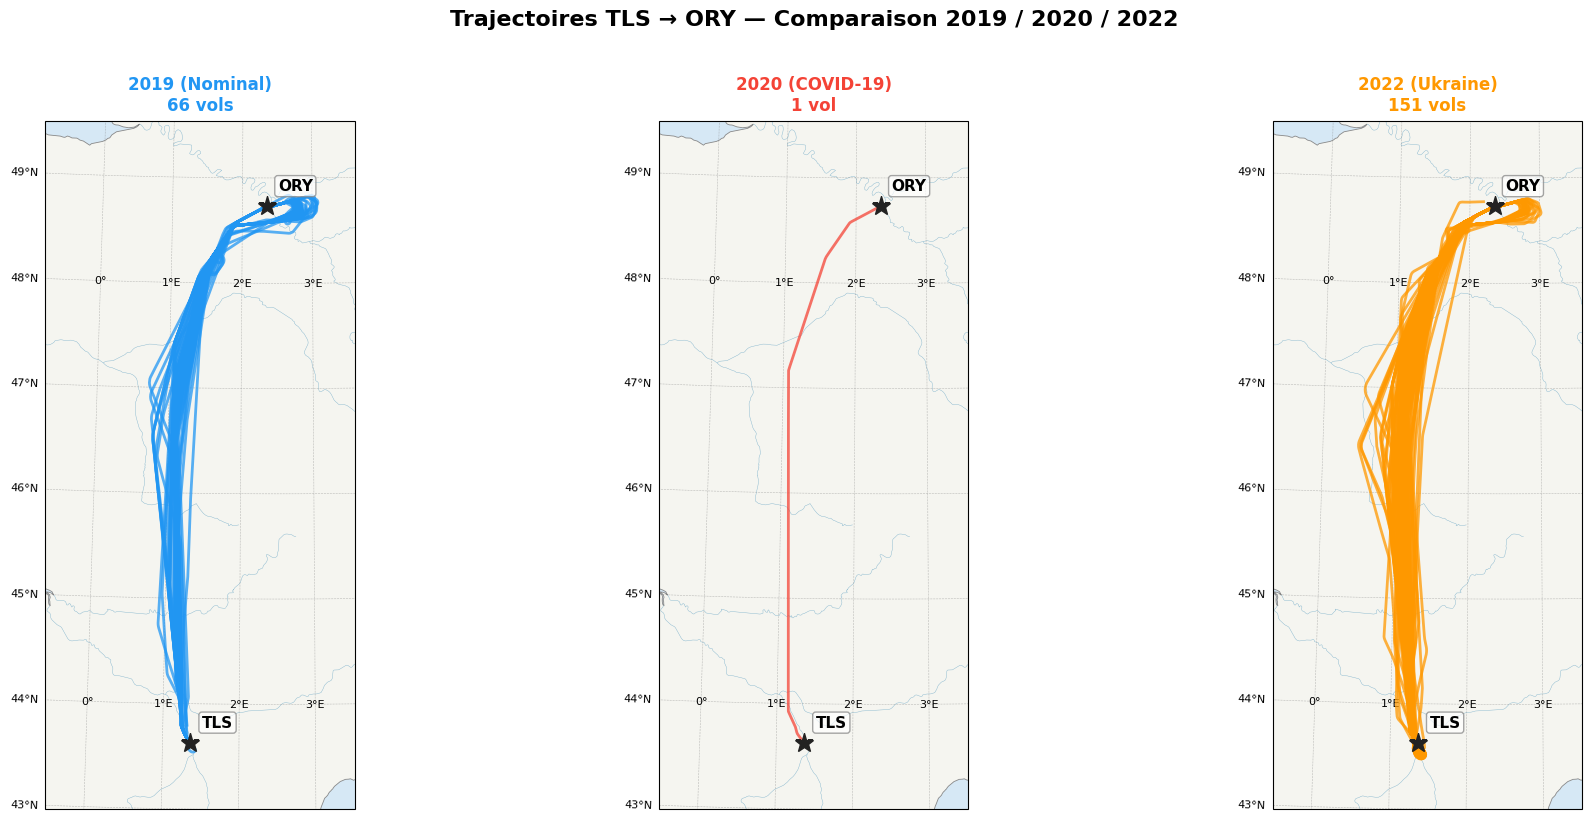

Carte sauvegardée : carte_trajectoires_TLS_ORY_v3.png


In [ ]:
def plot_trajectories_map(flights_by_day: dict, figsize=(20, 8)):
    proj = ccrs.LambertConformal(central_longitude=2.5, central_latitude=46.5, standard_parallels=(44, 49))
    fig, axes = plt.subplots(1, len(flights_by_day), figsize=figsize, subplot_kw={"projection": proj})
    fig.suptitle(f"Trajectoires {ORIGIN_IATA} → {DEST_IATA} — Comparaison 2019 / 2020 / 2022", fontsize=16, fontweight="bold", y=1.02)

    for ax, (label, flights) in zip(axes, flights_by_day.items()):
        color = COLORS[label]
        ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,      facecolor="#f5f5f0", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="#d6e8f5", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#888", zorder=1)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor="#aaa", linestyle="--", zorder=1)
        ax.add_feature(cfeature.RIVERS,    linewidth=0.3, edgecolor="#80b3cc", zorder=1)

        for apt_iata, apt in [(ORIGIN_IATA, tls_airport), (DEST_IATA, ory_airport)]:
            ax.plot(apt.longitude, apt.latitude, transform=ccrs.PlateCarree(), marker="*", markersize=14, color="#222", zorder=5)
            ax.text(apt.longitude + 0.15, apt.latitude + 0.15, apt_iata, transform=ccrs.PlateCarree(), fontsize=11, fontweight="bold", zorder=6, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7))
        if flights:
            for flight in flights:
                flight.plot(ax, color=color, alpha=0.75, linewidth=2.0, transform=ccrs.PlateCarree(), zorder=3)
            title_suffix = f"{len(flights)} vol{'s' if len(flights) > 1 else ''}"
        else:
            title_suffix = "Aucun vol détecté"
            ax.text(0.5, 0.5, "Aucun vol\ndétecté", transform=ax.transAxes, ha="center", va="center", fontsize=14, color="red", fontweight="bold")

        ax.set_title(f"{label}\n{title_suffix}", fontsize=12, fontweight="bold", color=color, pad=8)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = gl.right_labels = False
        gl.xlabel_style = gl.ylabel_style = {"size": 8}

    plt.tight_layout()
    #plt.savefig("carte_trajectoires_TLS_ORY_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Carte sauvegardée : carte_trajectoires_TLS_ORY_v3.png")

plot_trajectories_map(flights_by_day)

---
### SAUVEGARDE DES DONNÉES DU CORRIDOR SÉLECTIONNÉ EN FORMAT PARQUET

In [ ]:
import os

all_valid_flights = []
for label, flights_list in flights_by_day.items():
    for f in flights_list:
        df_temp = f.data.copy()
        df_temp["periode_etude"] = label
        all_valid_flights.append(df_temp)

if len(all_valid_flights) > 0:
    df_export = pd.concat(all_valid_flights, ignore_index=True)
    filename = f"trajectoires_{ORIGIN_IATA}_{DEST_IATA}.parquet"
    df_export.to_parquet(filename, index=False, engine="pyarrow")
    file_size_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"Les données pour le vol {ORIGIN_IATA} → {DEST_IATA} ont été sauvegardées.")
    print(f"Fichier créé : '{filename}' dans le répertoire courant.")
    print(f"Total : {len(all_valid_flights)} vols sauvegardés ({len(df_export)} points ADS-B, taille : {file_size_mb:.2f} Mo).")
else:
    print(f"Aucun vol valide trouvé pour le trajet {ORIGIN_IATA} → {DEST_IATA}. Aucun fichier n'a été créé.")

Succès ! Les données pour le vol TLS → ORY ont été sauvegardées.
Fichier créé : 'trajectoires_TLS_ORY.parquet' dans le répertoire courant.
Total : 218 vols sauvegardés (79455 points ADS-B, taille : 3.56 Mo).


---

## 7. Profils d'altitude

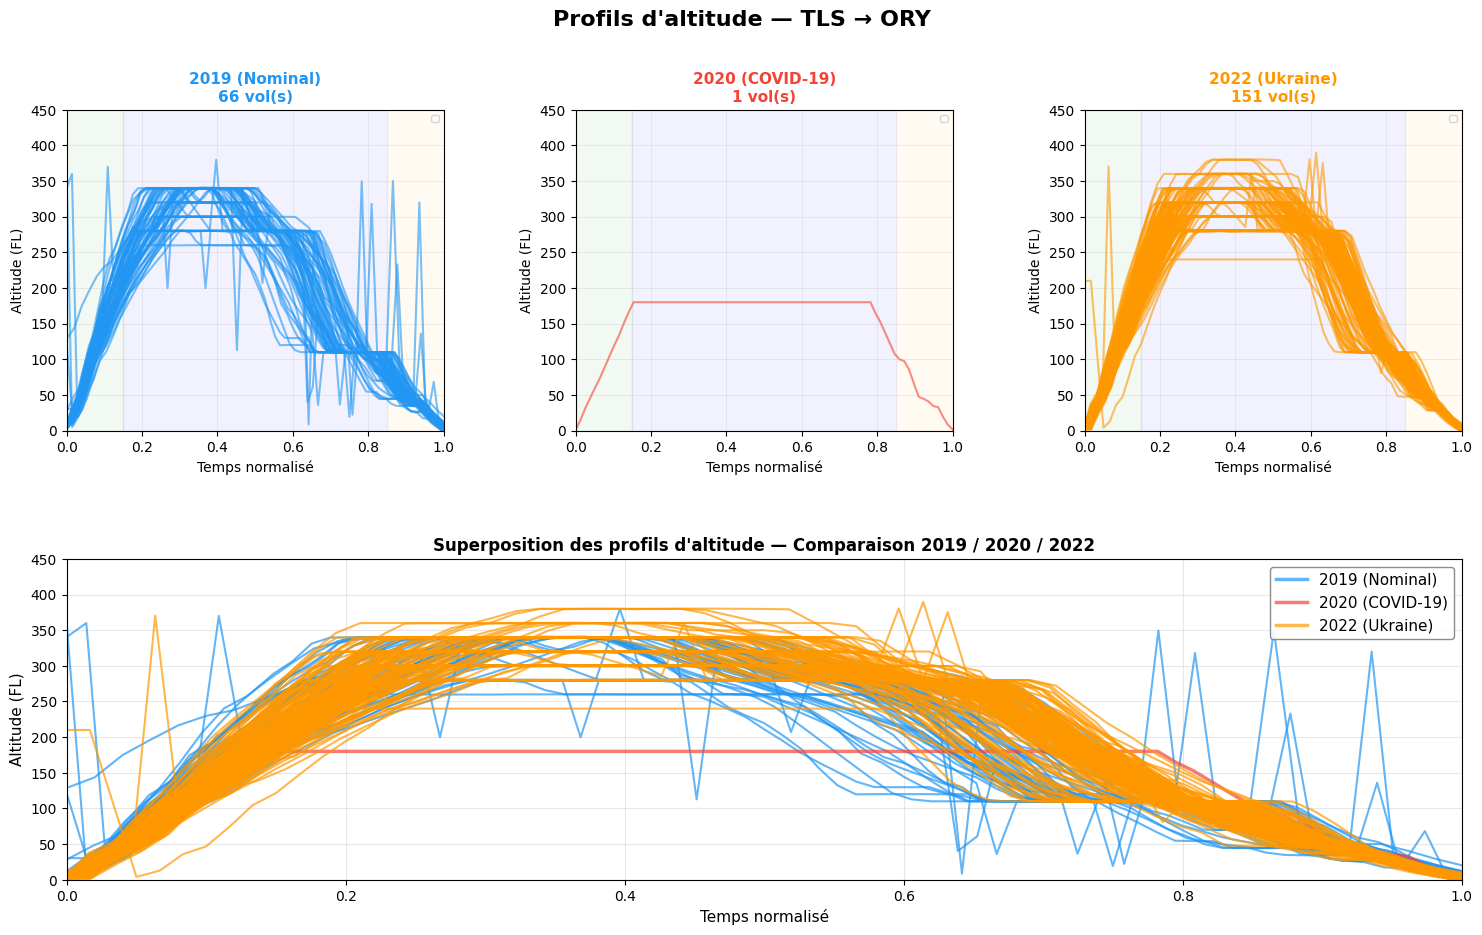

Figure sauvegardée : profils_altitude_TLS_ORY_v3.png


In [ ]:
def get_normalized_altitude_profile(flight: Flight) -> tuple[np.ndarray, np.ndarray] | None:
    try:
        f_r = flight.resample("60s") or flight
    except Exception:
        f_r = flight
    df = f_r.data.sort_values("timestamp").dropna(subset=["altitude"])
    if len(df) < 5:
        return None
    t0, t1 = df["timestamp"].iloc[0], df["timestamp"].iloc[-1]
    duration = (t1 - t0).total_seconds()
    if duration <= 0:
        return None
    t_norm = (df["timestamp"] - t0).dt.total_seconds().values / duration
    alt_fl  = df["altitude"].values / 100  # ft → FL
    return t_norm, alt_fl

def plot_altitude_profiles(flights_by_day: dict, figsize=(18, 10)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(f"Profils d'altitude — {ORIGIN_IATA} → {DEST_IATA}", fontsize=16, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    for col_idx, (label, flights) in enumerate(flights_by_day.items()):
        ax    = fig.add_subplot(gs[0, col_idx])
        color = COLORS[label]
        if not flights:
            ax.text(0.5, 0.5, "Aucun vol", transform=ax.transAxes, ha="center", va="center", fontsize=12, color="red")
            ax.set_title(label, fontsize=11, color=color)
            continue
        for flight in flights:
            p = get_normalized_altitude_profile(flight)
            if p is None: continue
            t_norm, alt_fl = p
            ax.plot(t_norm, alt_fl, color=color, alpha=0.6, linewidth=1.5)
        ax.axvspan(0,    0.15, alpha=0.05, color="green")
        ax.axvspan(0.15, 0.85, alpha=0.05, color="blue")
        ax.axvspan(0.85, 1.0,  alpha=0.05, color="orange")
        ax.set_xlabel("Temps normalisé", fontsize=10)
        ax.set_ylabel("Altitude (FL)", fontsize=10)
        ax.set_title(f"{label}\n{len(flights)} vol(s)", fontsize=11, color=color, fontweight="bold")
        ax.set_ylim(0, 450); ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        ax.legend(fontsize=7, loc="upper right")

    ax_ov = fig.add_subplot(gs[1, :])

    for label, flights in flights_by_day.items():
        color = COLORS[label]
        for i, flight in enumerate(flights):
            p = get_normalized_altitude_profile(flight)
            if p is None: continue
            t_norm, alt_fl = p
            ax_ov.plot(t_norm, alt_fl, color=color, alpha=0.7, linewidth=2.5 if i == 0 else 1.5, label=label if i == 0 else "_nolegend_")

    ax_ov.set_xlabel("Temps normalisé", fontsize=11)
    ax_ov.set_ylabel("Altitude (FL)", fontsize=11)
    ax_ov.set_title("Superposition des profils d'altitude — Comparaison 2019 / 2020 / 2022", fontsize=12, fontweight="bold")
    ax_ov.set_ylim(0, 450); ax_ov.set_xlim(0, 1)
    ax_ov.grid(True, alpha=0.3)
    ax_ov.legend(fontsize=11, loc="upper right", framealpha=0.9, edgecolor="gray")

    #plt.savefig("profils_altitude_TLS_ORY_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : profils_altitude_TLS_ORY_v3.png")

plot_altitude_profiles(flights_by_day)

---

## 8. Inspection individuelle des vols retenus

In [12]:
for label, flights in flights_by_day.items():
    print(f"\n{'═'*70}")
    print(f" {label} — {len(flights)} vol(s)")
    print(f"{'═'*70}")
    print(f"  {'Callsign':<12} {'Durée (min)':>12} {'Alt max FL':>11} "
          f"{'Lat départ':>11} {'Lon départ':>11} {'Lat arr':>9} {'Lon arr':>9}")
    print(f"  {'-'*12} {'-'*12} {'-'*11} {'-'*11} {'-'*11} {'-'*9} {'-'*9}")

    for f in flights:
        df = f.data.sort_values("timestamp")
        dur = (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds() / 60
        alt = df["altitude"].max() / 100 if "altitude" in df.columns else float("nan")
        print(
            f"  {str(f.callsign):<12} {dur:>12.1f} {alt:>10.0f} "
            f"  {df['latitude'].iloc[0]:>10.3f} {df['longitude'].iloc[0]:>11.3f}"
            f"  {df['latitude'].iloc[-1]:>9.3f} {df['longitude'].iloc[-1]:>9.3f}"
        )


══════════════════════════════════════════════════════════════════════
 2019 (Nominal) — 66 vol(s)
══════════════════════════════════════════════════════════════════════
  Callsign      Durée (min)  Alt max FL  Lat départ  Lon départ   Lat arr   Lon arr
  ------------ ------------ ----------- ----------- ----------- --------- ---------
  AFR16LZ              62.2        340       43.632       1.358     48.725     2.392
  AFR37TT              71.7        341       43.633       1.362     48.726     2.392
  AFR36TQ              64.8        341       43.638       1.352     48.725     2.392
  AFR57SP              67.5        340       43.632       1.364     48.726     2.393
  AFR33SL              65.7        280       43.640       1.356     48.725     2.391
  AFR52VC              72.3        340       43.632       1.363     48.725     2.389
  AFR33SL              57.2        341       43.632       1.363     48.734     2.357
  AFR36SP              55.8        300       43.634       1.362   

---

## 9. Métriques

In [ ]:
!pip install geopy
from geopy.distance import geodesic

def compute_flight_metrics(flight: Flight) -> dict | None:
    df = flight.data.sort_values("timestamp").dropna(subset=["altitude"]).reset_index(drop=True)
    if len(df) < 10:
        return None
    t0, t1       = df["timestamp"].iloc[0], df["timestamp"].iloc[-1]
    duration_min = (t1 - t0).total_seconds() / 60
    n             = len(df)
    central       = df.iloc[int(n*0.2):int(n*0.8)]
    alt_cruise_fl = central["altitude"].median() / 100
    alt_max_fl    = df["altitude"].max()       / 100
    gs_mean_kt = df["groundspeed"].dropna().mean() if "groundspeed" in df.columns else np.nan
    lats           = df["latitude"].values
    lons           = df["longitude"].values
    dist_actual_km = sum(
        geodesic((lats[i], lons[i]), (lats[i+1], lons[i+1])).km
        for i in range(len(lats) - 1)
    )
    dist_ortho_km = geodesic((tls_airport.latitude, tls_airport.longitude),(ory_airport.latitude, ory_airport.longitude)).km
    hfe = dist_ortho_km / dist_actual_km if dist_actual_km > 0 else np.nan
    if "vertical_rate" in df.columns:
        vr     = df["vertical_rate"].dropna()
        vr_max = vr.max()
        vr_min = vr.min()
    else:
        vr_max = vr_min = np.nan
    callsign = flight.callsign or (
        df["callsign"].dropna().iloc[0] if "callsign" in df.columns and not df["callsign"].dropna().empty
        else "UNKNOWN"
    )
    return {
        "callsign":       callsign,
        "n_points":       len(df),
        "depart_utc":     t0.strftime("%H:%M UTC"),
        "arrivee_utc":    t1.strftime("%H:%M UTC"),
        "duration_min":   round(duration_min,  1),
        "alt_cruise_FL":  round(alt_cruise_fl, 0),
        "alt_max_FL":     round(alt_max_fl,    0),
        "gs_mean_kt":     round(gs_mean_kt,    1) if not np.isnan(gs_mean_kt) else np.nan,
        "dist_actual_km": round(dist_actual_km,1),
        "dist_ortho_km":  round(dist_ortho_km, 1),
        "HFE":            round(hfe,            4) if not np.isnan(hfe) else np.nan,
        "vrate_max_fpm":  round(vr_max,         0) if not np.isnan(vr_max) else np.nan,
        "vrate_min_fpm":  round(vr_min,         0) if not np.isnan(vr_min) else np.nan,
    }

print("Calcul des métriques par vol...\n")
metrics_by_day = {}
for label, flights in flights_by_day.items():
    metrics_list = [m for f in flights if (m := compute_flight_metrics(f)) is not None]
    if metrics_list:
        df_m = pd.DataFrame(metrics_list)
        df_m.insert(0, "journee", label)
        metrics_by_day[label] = df_m
        print(f"{label} : {len(df_m)} vol(s)")
    else:
        print(f"{label} : Aucun vol avec métriques valides")
        metrics_by_day[label] = pd.DataFrame()
    print()

all_metrics = pd.concat(metrics_by_day.values(), ignore_index=True)
all_metrics.to_csv("metriques_vols_TLS_ORY_v3.csv", index=False)
print(f"\n{len(all_metrics)} vols exportés → metriques_vols_TLS_ORY_v3.csv")

Calcul des métriques par vol...

▶ 2019 (Nominal) : 66 vol(s)


,callsign,n_points,depart_utc,arrivee_utc,duration_min,alt_cruise_FL,alt_max_FL,gs_mean_kt,dist_actual_km,dist_ortho_km,HFE,vrate_max_fpm,vrate_min_fpm
0,AFR16LZ,373,09:37 UTC,10:39 UTC,62.2,254.0,340.0,354.6,679.8,572.1,0.8415,3776.0,-2624.0
1,AFR37TT,425,06:32 UTC,07:44 UTC,71.7,280.0,341.0,307.4,681.2,572.1,0.8398,4032.0,-2112.0
2,AFR36TQ,389,08:47 UTC,09:52 UTC,64.8,280.0,341.0,336.3,673.7,572.1,0.8492,3392.0,-3264.0
3,AFR57SP,405,19:38 UTC,20:46 UTC,67.5,294.0,340.0,318.7,675.4,572.1,0.8470,4032.0,-2560.0
4,AFR33SL,394,05:12 UTC,06:18 UTC,65.7,253.0,280.0,338.7,686.4,572.1,0.8334,3392.0,-2752.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,EZY517J,338,13:08 UTC,14:04 UTC,56.3,285.0,330.0,346.3,600.2,572.1,0.9532,3840.0,-3840.0
62,EZY723C,410,16:34 UTC,17:42 UTC,68.3,280.0,318.0,326.3,679.8,572.1,0.8415,4352.0,-2880.0
63,EJU286C,303,18:22 UTC,19:12 UTC,50.5,277.0,280.0,384.5,598.4,572.1,0.9560,4800.0,-2944.0
64,EZY769H,376,18:53 UTC,19:55 UTC,62.7,280.0,351.0,308.6,597.1,572.1,0.9581,4096.0,-3072.0



▶ 2020 (COVID-19) : 1 vol(s)


,callsign,n_points,depart_utc,arrivee_utc,duration_min,alt_cruise_FL,alt_max_FL,gs_mean_kt,dist_actual_km,dist_ortho_km,HFE,vrate_max_fpm,vrate_min_fpm
0,NAK083,471,06:58 UTC,08:16 UTC,78.7,180.0,180.0,248.0,602.0,572.1,0.9503,2112.0,-2176.0



▶ 2022 (Ukraine) : 151 vol(s)


,callsign,n_points,depart_utc,arrivee_utc,duration_min,alt_cruise_FL,alt_max_FL,gs_mean_kt,dist_actual_km,dist_ortho_km,HFE,vrate_max_fpm,vrate_min_fpm
0,AFR62UX,362,10:53 UTC,11:53 UTC,60.3,311.0,320.0,335.5,624.6,572.1,0.9160,4352.0,-2560.0
1,AFR16RA,361,12:00 UTC,13:00 UTC,60.2,300.0,300.0,343.5,636.9,572.1,0.8983,5312.0,-2496.0
2,AFR17ZX,326,16:35 UTC,17:31 UTC,56.0,280.0,281.0,362.1,630.0,572.1,0.9082,4544.0,-2816.0
3,AFR27CX,347,09:12 UTC,10:10 UTC,57.8,293.0,300.0,352.0,628.2,572.1,0.9106,4288.0,-2560.0
4,AFR66NY,346,07:08 UTC,08:06 UTC,57.7,311.0,360.0,351.0,624.5,572.1,0.9161,4672.0,-3328.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,EJU986W,345,15:20 UTC,16:18 UTC,57.5,291.0,320.0,345.7,614.5,572.1,0.9310,4096.0,-2816.0
147,EJU394Y,348,06:32 UTC,07:29 UTC,57.8,316.0,340.0,337.0,603.1,572.1,0.9486,3712.0,-3968.0
148,EJU474F,320,20:21 UTC,21:15 UTC,53.3,320.0,341.0,383.5,632.1,572.1,0.9051,6272.0,-2880.0
149,EJU485C,322,12:52 UTC,13:46 UTC,53.7,292.0,370.0,383.3,632.5,572.1,0.9045,3648.0,-4800.0




218 vols exportés → metriques_vols_TLS_ORY_v3.csv


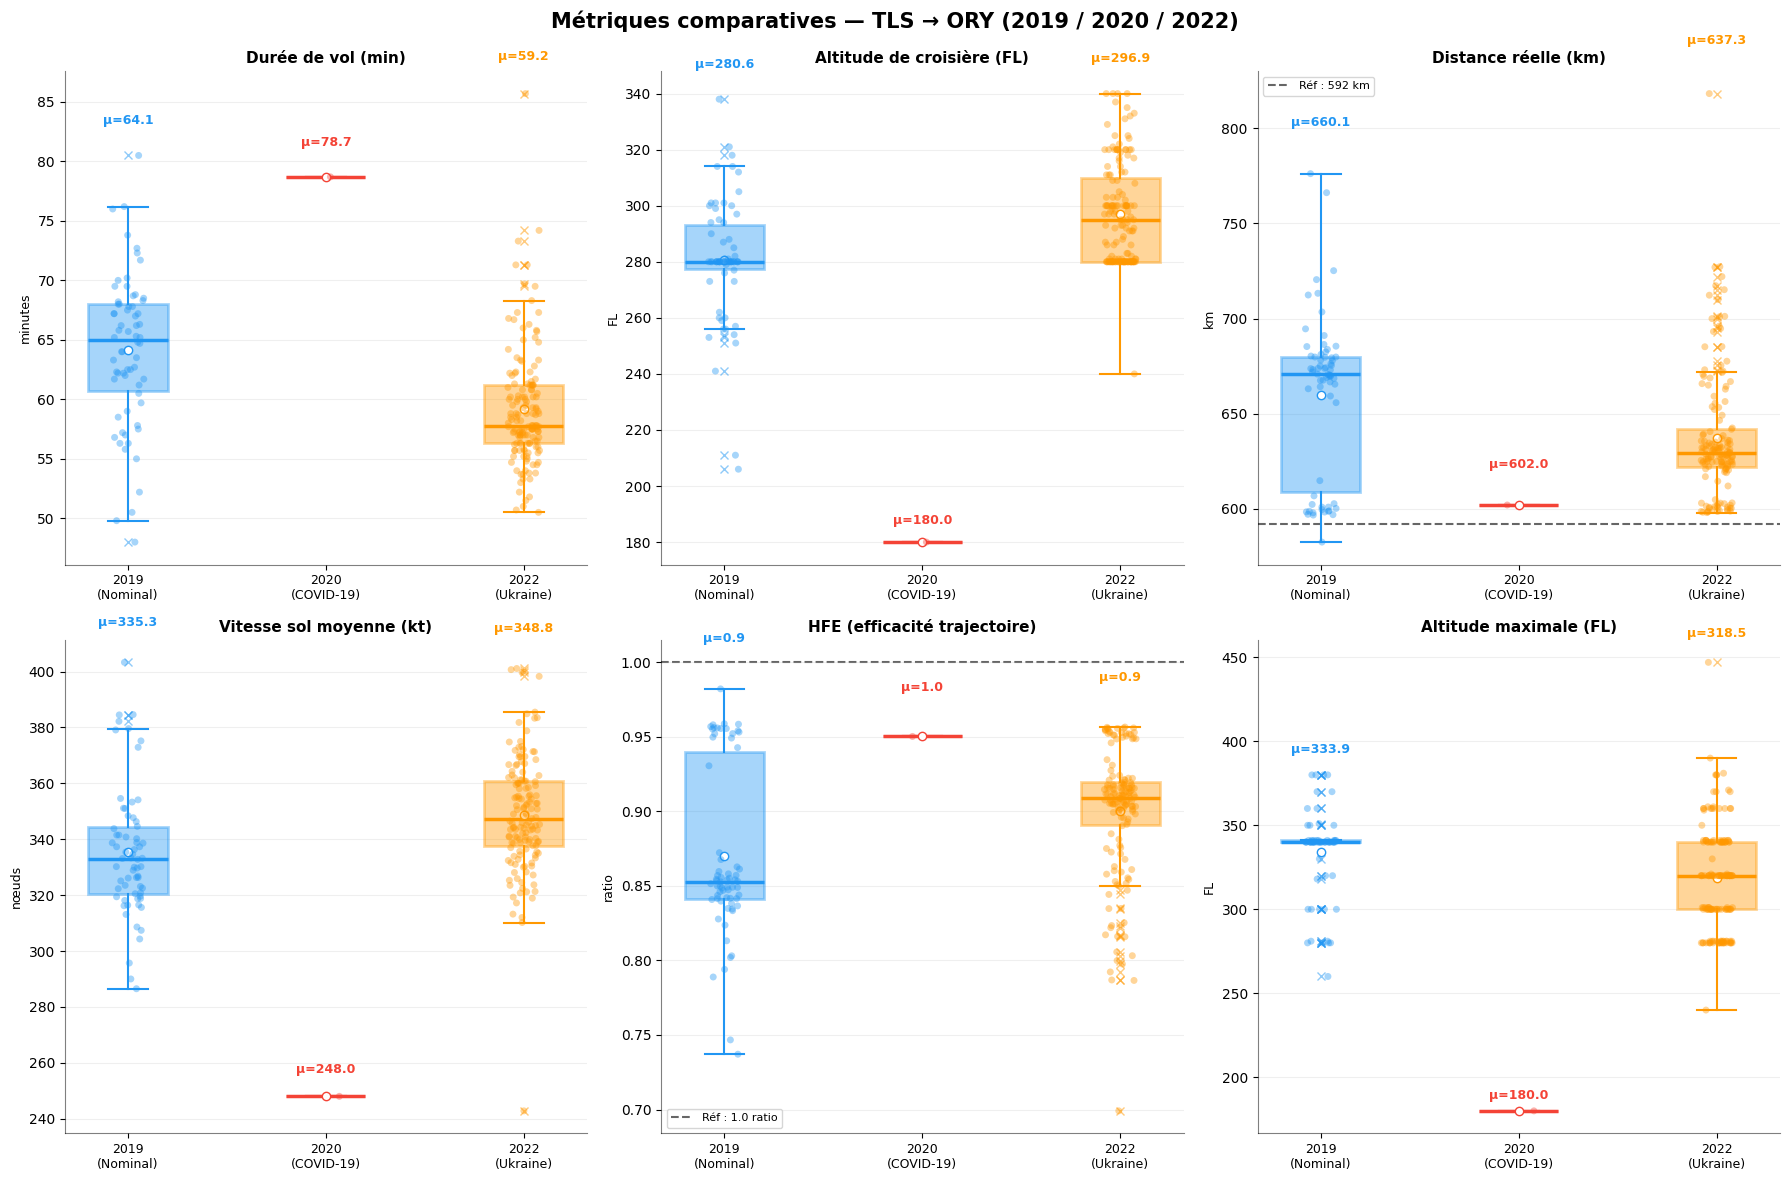

Figure sauvegardée : metriques_comparatives_boxplots_TLS_ORY.png


In [ ]:
def plot_metrics_comparison(metrics_by_day: dict, figsize=(18, 12)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f"Métriques comparatives — {ORIGIN_IATA} → {DEST_IATA} (2019 / 2020 / 2022)", fontsize=15, fontweight="bold")
    metrics_config = [
        ("duration_min",   "Durée de vol (min)",          "minutes",  None),
        ("alt_cruise_FL",  "Altitude de croisière (FL)",  "FL",       None),
        ("dist_actual_km", "Distance réelle (km)",        "km",       592),
        ("gs_mean_kt",     "Vitesse sol moyenne (kt)",    "nœuds",    None),
        ("HFE",            "HFE (efficacité trajectoire)","ratio",    1.0),
        ("alt_max_FL",     "Altitude maximale (FL)",      "FL",       None),
    ]
    labels = list(metrics_by_day.keys())
    colors = [COLORS[l] for l in labels]
    
    for ax, (col, title, unit, ref_val) in zip(axes.flatten(), metrics_config):
        values = []
        valid_labels = []
        valid_colors = []
        for label in labels:
            df_m = metrics_by_day[label]
            if not df_m.empty and col in df_m.columns:
                vals = df_m[col].dropna().tolist()
                if len(vals) > 0:
                    values.append(vals)
                    valid_labels.append(label)
                    valid_colors.append(COLORS[label])
                else:
                    values.append([])
            else:
                values.append([])
        x_pos = np.arange(len(labels))
        
        if any(len(v) > 0 for v in values):
            clean_values = [v for v in values if len(v) > 0]
            clean_positions = [i for i, v in enumerate(values) if len(v) > 0]
            bp = ax.boxplot(clean_values, positions=clean_positions, widths=0.4, patch_artist=True,showmeans=True, zorder=2, manage_ticks=False)
            for i, idx in enumerate(clean_positions):
                color = colors[idx]
                bp['boxes'][i].set(facecolor=color, alpha=0.4, edgecolor=color, linewidth=2)
                bp['whiskers'][2*i].set(color=color, linewidth=1.5, linestyle="-")
                bp['whiskers'][2*i+1].set(color=color, linewidth=1.5, linestyle="-")
                bp['caps'][2*i].set(color=color, linewidth=1.5)
                bp['caps'][2*i+1].set(color=color, linewidth=1.5)
                bp['medians'][i].set(color=color, linewidth=2.5)
                bp['means'][i].set(markerfacecolor='white', markeredgecolor=color, marker='o', markersize=6)
                bp['fliers'][i].set(marker='x', markeredgecolor=color, alpha=0.5)
            for i, vals in enumerate(values):
                if len(vals) > 0:
                    color = colors[i]
                    jitter = np.random.uniform(-0.08, 0.08, len(vals))
                    ax.scatter([i + j for j in jitter], vals, color=color, alpha=0.4, s=25, zorder=3, edgecolors='none')
                    mean_val = np.mean(vals)
                    ax.text(i, max(vals) * 1.03, f"μ={mean_val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color=color)
        for i, vals in enumerate(values):
            if len(vals) == 0:
                ax.text(i, 0.5, "N/A", ha="center", va="center", fontsize=11, color="gray", transform=ax.get_xaxis_transform())

        if ref_val is not None:
            ax.axhline(y=ref_val, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1, label=f"Réf : {ref_val} {unit}")
            ax.legend(fontsize=8, loc="best")
        ax.set_xticks(x_pos)
        ax.set_xticklabels([l.replace(" ", "\n") for l in labels], fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel(unit, fontsize=9)
        ax.grid(True, axis="y", alpha=0.2, linestyle="-")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)
    
    plt.tight_layout()
    #plt.savefig("metriques_comparatives_boxplots_TLS_ORY.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : metriques_comparatives_boxplots_TLS_ORY.png")

plot_metrics_comparison(metrics_by_day)

---
## 10. Clustering HDBSCAN

In [ ]:
import hdbscan
from sklearn.preprocessing import StandardScaler

N_POINTS_RESAMPLE = 60 
HDBSCAN_MIN_CLUSTER_SIZE = 12 
HDBSCAN_MIN_SAMPLES      = 1
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'P', '*', 'X', 'v', '<', '>']
OUTLIER_COLOR   = '#AAAAAA'
OUTLIER_MARKER  = 'x'

def trajectoire_en_vecteur(flight: 'Flight', n_points: int = N_POINTS_RESAMPLE) -> 'np.ndarray | None':
    try:
        df_raw = flight.data.dropna(subset=['latitude', 'longitude', 'timestamp'])
        if len(df_raw) < 5:
            return None
        t0 = df_raw['timestamp'].min()
        t1 = df_raw['timestamp'].max()
        duree_s = (t1 - t0).total_seconds()
        if duree_s <= 0:
            return None
        freq_s = max(1, int(duree_s / (n_points - 1)))
        try:
            f_resampled = flight.resample(f"{freq_s}s")
            df = f_resampled.data.dropna(subset=['latitude', 'longitude']).sort_values('timestamp')
        except Exception:
            df = df_raw.sort_values('timestamp')
        if len(df) < 5:
            return None
        t_raw = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds().values
        t_max = t_raw[-1]
        if t_max <= 0:
            return None
        progress     = t_raw / t_max
        targets      = np.linspace(0, 1, n_points)
        lats_interp  = np.interp(targets, progress, df['latitude'].values)
        lons_interp  = np.interp(targets, progress, df['longitude'].values)
        vecteur = np.empty(2 * n_points)
        vecteur[0::2] = lats_interp
        vecteur[1::2] = lons_interp
        return vecteur
    except Exception:
        return None

def construire_matrice(flights: 'list[Flight]', n_points: int = N_POINTS_RESAMPLE) -> 'tuple[np.ndarray, list[str]]':
    vecteurs   = []
    callsigns  = []
    for f in flights:
        v = trajectoire_en_vecteur(f, n_points)
        if v is not None:
            vecteurs.append(v)
            callsigns.append(str(f.callsign))
    if not vecteurs:
        return np.array([]).reshape(0, 2 * n_points), []
    X = np.vstack(vecteurs)
    print(f"Matrice : {X.shape[0]} vols × {X.shape[1]} features")
    return X, callsigns

In [ ]:
def clusterer_periode(flights: 'list[Flight]', label: str) -> dict:
    if not flights:
        print("Aucun vol disponible.")
        return {}
    X, callsigns = construire_matrice(flights)
    if len(X) < 2:
        print(f"Trop peu de vols vectorisés ({len(X)}) pour clustériser.")
        return {}
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clusterer    = hdbscan.HDBSCAN(min_cluster_size = HDBSCAN_MIN_CLUSTER_SIZE, min_samples = HDBSCAN_MIN_SAMPLES, metric = 'euclidean')
    labels = clusterer.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = int(np.sum(labels == -1))
    n_total    = len(labels)
    print(f"Clusters trouvés        : {n_clusters}")
    print(f"Vols outliers (label -1): {n_noise}/{n_total} ({100*n_noise/n_total:.0f}%)")
    for c in sorted(set(labels)):
        mask = labels == c
        nom  = f"Cluster {c}" if c >= 0 else "Outliers"
        cs   = [callsigns[i] for i in range(len(callsigns)) if mask[i]]
        print(f"   {nom:12s}: {mask.sum()} vol(s) → {', '.join(cs)}")

    cs_set    = set(callsigns)
    flights_ok = [f for f in flights if str(f.callsign) in cs_set]
    return {'X' : X, 'X_scaled' : X_scaled, 'labels' : labels, 'callsigns' : callsigns, 'n_clusters' : n_clusters, 'n_noise' : n_noise, 'flights_ok' : flights_ok}

resultats_clustering: dict[str, dict] = {}
for label, flights in flights_by_day.items():
    resultats_clustering[label] = clusterer_periode(flights, label)
print("\nClustering terminé pour toutes les périodes.")

Matrice : 66 vols × 120 features
Clusters trouvés        : 2
Vols outliers (label -1): 15/66 (23%)
   Outliers    : 15 vol(s) → AFR52VC, AFR69PR, AFR88QR, AFR69NT, AFR32AM, AFR53VQ, AFR18RR, AFR69PR, AFR57MB, AFR28SG, AFR92RA, AFR89DH, AFR52VV, EZY4020, EJU504U
   Cluster 0   : 39 vol(s) → AFR16LZ, AFR37TT, AFR36TQ, AFR57SP, AFR33SL, AFR33SL, AFR36TQ, AFR16ZA, AFR55JX, AFR18RR, AFR52VC, AFR52VC, AFR18RR, AFR18RR, AFR52VC, AFR53VQ, AFR92RA, AFR69PR, AFR19TA, AFR52VV, AFR37TT, AFR52VV, AFR44PH, AFR33SL, AFR56SQ, AFR77KP, AFR37TT, AFR37TT, AFR16LZ, AFR27PA, AFR56SQ, AFR16LZ, AFR56SQ, EZY769H, EZY4020, EZY957E, EZY723C, EZY723C, EZY157K
   Cluster 1   : 12 vol(s) → AFR36SP, AFR69NT, AFR57SP, AFR64RM, AFR19TA, AFR56SQ, AFR78KP, AFR65GD, AFR52VV, EZY517J, EJU286C, EZY769H
Matrice : 1 vols × 120 features
Trop peu de vols vectorisés (1) pour clustériser.
Matrice : 151 vols × 120 features
Clusters trouvés        : 3
Vols outliers (label -1): 13/151 (9%)
   Outliers    : 13 vol(s) → AFR62UX, AFR

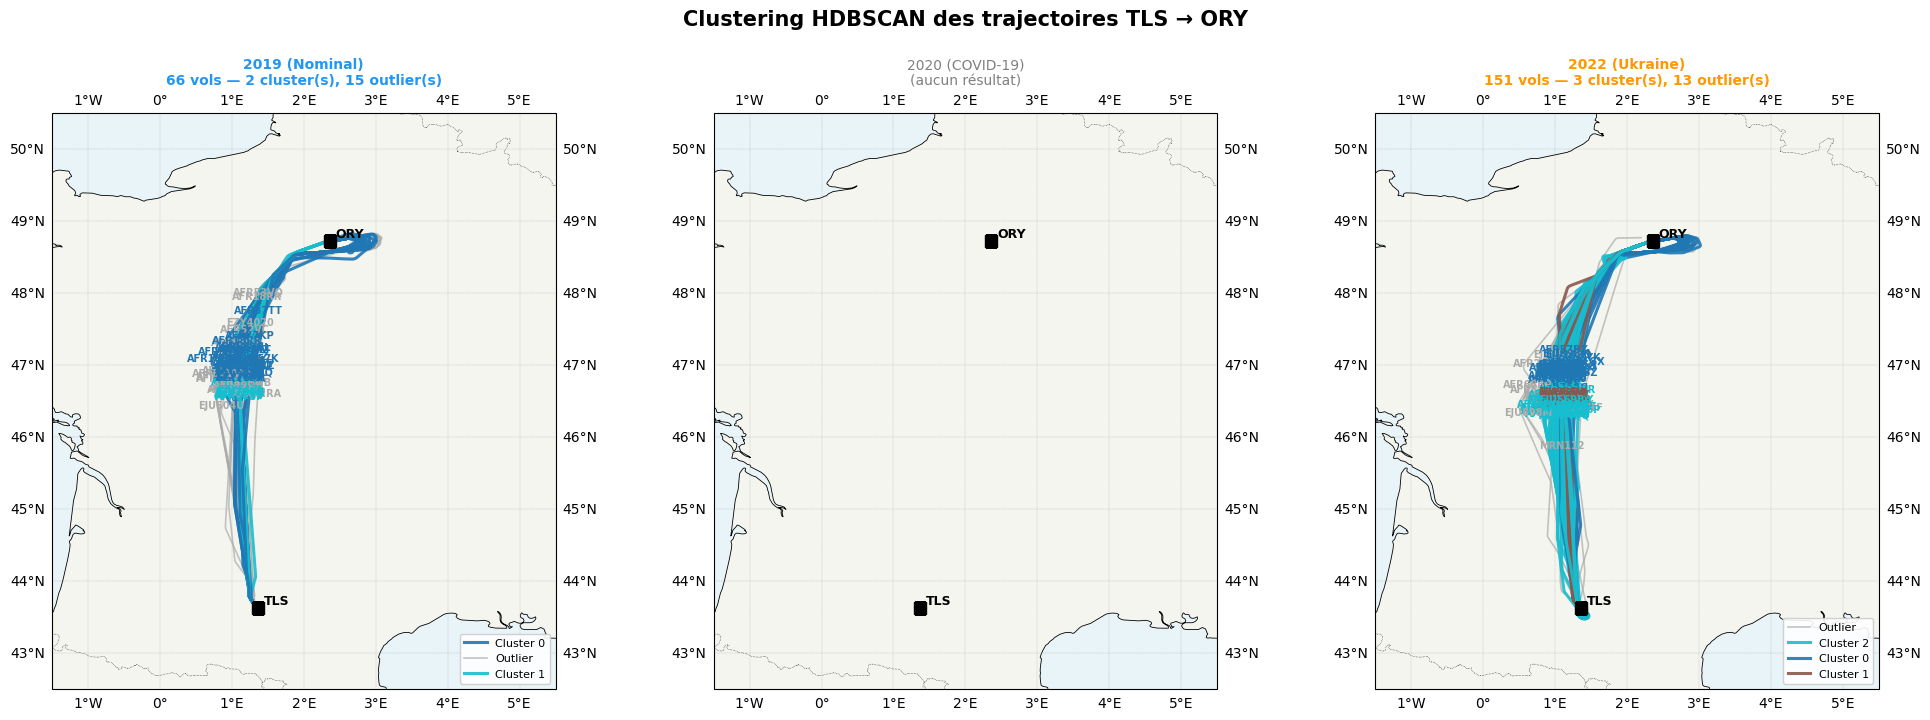

Figure sauvegardée : clustering_HDBSCAN_TLS_ORY.png


In [ ]:
def plot_clusters_carte(resultats: dict, figsize: tuple = (20, 7)) -> None:
    labels_periodes = list(resultats.keys())
    n_cols          = len(labels_periodes)
    fig, axes = plt.subplots(1, n_cols, figsize  = figsize, subplot_kw = {'projection': ccrs.PlateCarree()})
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(f"Clustering HDBSCAN des trajectoires {ORIGIN_IATA} → {DEST_IATA}", fontsize=15, fontweight='bold', y=1.01)

    for ax, label in zip(axes, labels_periodes):
        res    = resultats[label]
        color  = COLORS[label]

        ax.set_extent([-1.5, 5.5, 42.5, 50.5], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,       facecolor='#F5F5F0', zorder=0)
        ax.add_feature(cfeature.OCEAN,      facecolor='#E8F4F8', zorder=0)
        ax.add_feature(cfeature.COASTLINE,  linewidth=0.6,       zorder=1)
        ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=':', zorder=1)
        ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                     alpha=0.5, linestyle='--', x_inline=False, y_inline=False)

        for apt, name in [(tls_airport, 'TLS'), (ory_airport, 'ORY')]:
            ax.plot(apt.longitude, apt.latitude, 's', color='black', markersize=8, zorder=5, transform=ccrs.PlateCarree())
            ax.text(apt.longitude + 0.08, apt.latitude + 0.05, name, fontsize=9, fontweight='bold', transform=ccrs.PlateCarree(), zorder=6)
        if not res:
            ax.set_title(f"{label}\n(aucun résultat)", fontsize=10, color='gray')
            continue
        flights_ok = res['flights_ok']
        labels_arr = res['labels']
        callsigns  = res['callsigns']

        unique_clusters = sorted(c for c in set(labels_arr) if c >= 0)
        cmap = plt.cm.get_cmap('tab10', max(len(unique_clusters), 1))
        cluster_colors = {c: cmap(i) for i, c in enumerate(unique_clusters)}

        for i, flight in enumerate(flights_ok):
            df = flight.data.sort_values('timestamp').dropna(subset=['latitude', 'longitude'])
            lbl  = labels_arr[i]
            cs   = callsigns[i]
            if lbl == -1:
                traj_color  = OUTLIER_COLOR
                lw          = 1.2
                alpha       = 0.7
                leg_label   = 'Outlier'
                zorder      = 2
            else:
                traj_color  = cluster_colors[lbl]
                lw          = 2.2
                alpha       = 0.9
                leg_label   = f'Cluster {lbl}'
                zorder      = 3
            ax.plot(df['longitude'].values, df['latitude'].values, color=traj_color, linewidth=lw, alpha=alpha, transform=ccrs.PlateCarree(), zorder=zorder, label=leg_label)
            mid = len(df) // 2
            ax.text(df['longitude'].iloc[mid], df['latitude'].iloc[mid] + 0.05, cs, fontsize=7, color=traj_color, transform=ccrs.PlateCarree(), zorder=6, ha='center', fontweight='bold')

        handles, leg_labels = ax.get_legend_handles_labels()
        seen   = {}
        h_uniq = []
        l_uniq = []
        for h, l in zip(handles, leg_labels):
            if l not in seen:
                seen[l] = True
                h_uniq.append(h)
                l_uniq.append(l)
        ax.legend(h_uniq, l_uniq, loc='lower right', fontsize=8, framealpha=0.9)

        n_cl = res['n_clusters']
        n_no = res['n_noise']
        n_vo = len(flights_ok)
        ax.set_title(f"{label}\n{n_vo} vols — {n_cl} cluster(s), {n_no} outlier(s)", fontsize=10, fontweight='bold', color=color)

    plt.tight_layout()
    #plt.savefig("clustering_HDBSCAN_TLS_ORY.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure sauvegardée : clustering_HDBSCAN_TLS_ORY.png")

plot_clusters_carte(resultats_clustering)

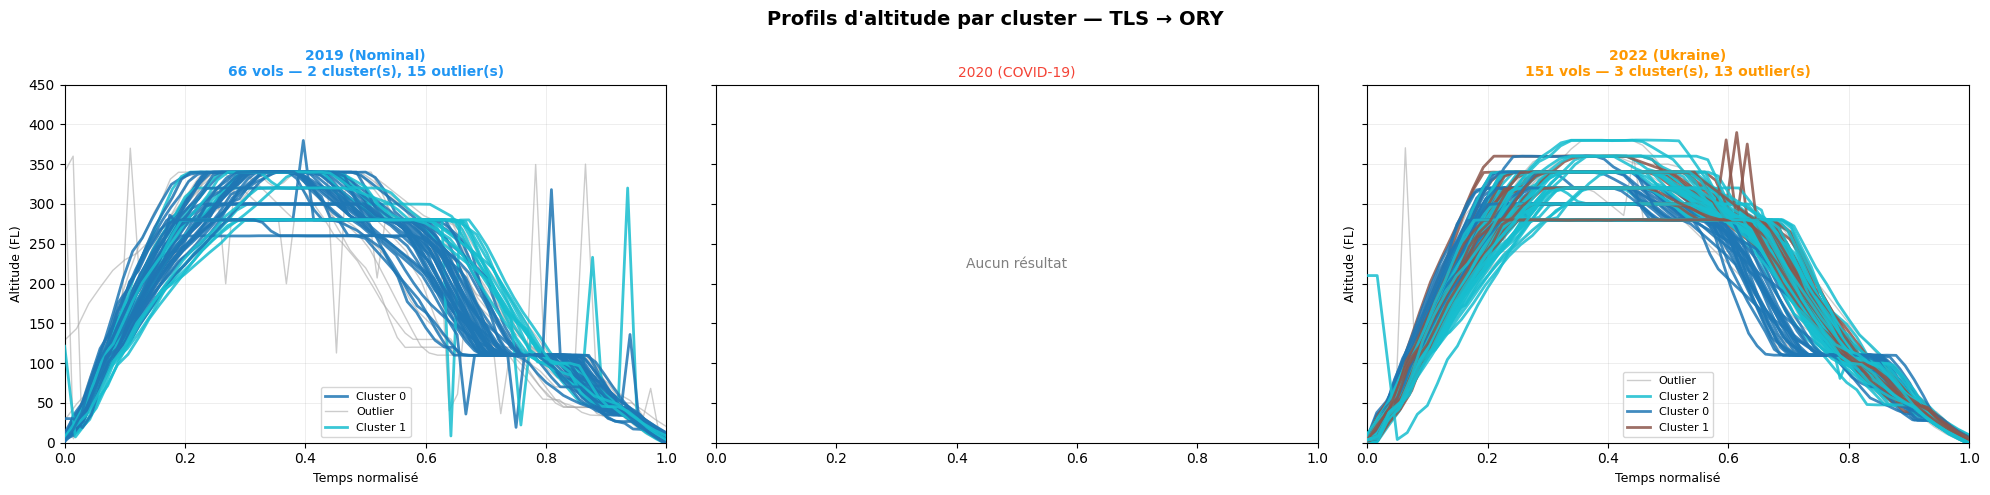

Figure sauvegardée : clustering_altitude_TLS_ORY.png


In [ ]:
def plot_altitude_par_cluster(resultats: dict, figsize: tuple = (20, 5)) -> None:
    labels_periodes = list(resultats.keys())
    n_cols          = len(labels_periodes)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize, sharey=True)
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(f"Profils d'altitude par cluster — {ORIGIN_IATA} → {DEST_IATA}", fontsize=14, fontweight='bold')
    for ax, label in zip(axes, labels_periodes):
        res   = resultats[label]
        color = COLORS[label]
        if not res:
            ax.text(0.5, 0.5, 'Aucun résultat', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_title(label, color=color, fontsize=10)
            continue
        flights_ok = res['flights_ok']
        labels_arr = res['labels']
        unique_clusters = sorted(c for c in set(labels_arr) if c >= 0)
        cmap            = plt.cm.get_cmap('tab10', max(len(unique_clusters), 1))
        cluster_colors  = {c: cmap(i) for i, c in enumerate(unique_clusters)}
        for i, flight in enumerate(flights_ok):
            try:
                f_r = flight.resample("60s")
            except Exception:
                f_r = flight
            df = f_r.data.sort_values('timestamp').dropna(subset=['altitude'])
            if len(df) < 5:
                continue
            t0, t1   = df['timestamp'].iloc[0], df['timestamp'].iloc[-1]
            dur_s    = (t1 - t0).total_seconds()
            if dur_s <= 0:
                continue
            t_norm   = (df['timestamp'] - t0).dt.total_seconds().values / dur_s
            alt_fl   = df['altitude'].values / 100
            lbl = labels_arr[i]
            if lbl == -1:
                traj_color = OUTLIER_COLOR
                lw, alpha  = 1.0, 0.6
                zorder     = 2
            else:
                traj_color = cluster_colors[lbl]
                lw, alpha  = 2.0, 0.85
                zorder     = 3
            ax.plot(t_norm, alt_fl, color=traj_color, linewidth=lw, alpha=alpha, zorder=zorder, label=f'Cluster {lbl}' if lbl >= 0 else 'Outlier')

        ax.set_xlabel("Temps normalisé", fontsize=9)
        ax.set_ylabel("Altitude (FL)", fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 450)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        handles, leg_labels_list = ax.get_legend_handles_labels()
        seen   = {}
        h_uniq, l_uniq = [], []
        for h, l in zip(handles, leg_labels_list):
            if l not in seen:
                seen[l] = True
                h_uniq.append(h)
                l_uniq.append(l)
        ax.legend(h_uniq, l_uniq, fontsize=8, loc='lower center')
        n_cl = res['n_clusters']
        n_no = res['n_noise']
        n_vo = len(flights_ok)
        ax.set_title(f"{label}\n{n_vo} vols — {n_cl} cluster(s), {n_no} outlier(s)", fontsize=10, fontweight='bold', color=color)

    plt.tight_layout()
    #plt.savefig("clustering_altitude_TLS_ORY.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure sauvegardée : clustering_altitude_TLS_ORY.png")

plot_altitude_par_cluster(resultats_clustering)

In [42]:
def afficher_recap_clusters(resultats: dict) -> None:
    print(f"\n{'═'*70}")
    print(f" Récapitulatif du clustering HDBSCAN — {ORIGIN_IATA} → {DEST_IATA}")
    print(f"{'═'*70}")

    for label, res in resultats.items():
        print(f"\n{label}")
        if not res:
            print("  (aucun résultat)")
            continue
        labels_arr = res['labels']
        callsigns  = res['callsigns']
        for c in sorted(set(labels_arr)):
            mask = labels_arr == c
            nom  = f"Cluster {c}" if c >= 0 else "Outliers (-1)"
            cs   = [callsigns[i] for i in range(len(callsigns)) if mask[i]]
            print(f"  {nom:14s}: {mask.sum():2d} vol(s) → {', '.join(cs)}")

afficher_recap_clusters(resultats_clustering)


══════════════════════════════════════════════════════════════════════
 Récapitulatif du clustering HDBSCAN — TLS → ORY
══════════════════════════════════════════════════════════════════════

2019 (Nominal)
  Outliers (-1) : 15 vol(s) → AFR52VC, AFR69PR, AFR88QR, AFR69NT, AFR32AM, AFR53VQ, AFR18RR, AFR69PR, AFR57MB, AFR28SG, AFR92RA, AFR89DH, AFR52VV, EZY4020, EJU504U
  Cluster 0     : 39 vol(s) → AFR16LZ, AFR37TT, AFR36TQ, AFR57SP, AFR33SL, AFR33SL, AFR36TQ, AFR16ZA, AFR55JX, AFR18RR, AFR52VC, AFR52VC, AFR18RR, AFR18RR, AFR52VC, AFR53VQ, AFR92RA, AFR69PR, AFR19TA, AFR52VV, AFR37TT, AFR52VV, AFR44PH, AFR33SL, AFR56SQ, AFR77KP, AFR37TT, AFR37TT, AFR16LZ, AFR27PA, AFR56SQ, AFR16LZ, AFR56SQ, EZY769H, EZY4020, EZY957E, EZY723C, EZY723C, EZY157K
  Cluster 1     : 12 vol(s) → AFR36SP, AFR69NT, AFR57SP, AFR64RM, AFR19TA, AFR56SQ, AFR78KP, AFR65GD, AFR52VV, EZY517J, EJU286C, EZY769H

2020 (COVID-19)
  (aucun résultat)

2022 (Ukraine)
  Outliers (-1) : 13 vol(s) → AFR62UX, AFR21HX, AFR57BX, AF

---
## 11. Comparaison clusters et périodes

In [ ]:
def trajectoire_mediane(flights: 'list[Flight]', n_points: int = N_POINTS_RESAMPLE) -> 'np.ndarray | None':
    vecteurs = [trajectoire_en_vecteur(f, n_points) for f in flights]
    vecteurs = [v for v in vecteurs if v is not None]
    if len(vecteurs) < 1:
        return None
    return np.median(np.array(vecteurs), axis=0)

def calculer_medianes_par_cluster(resultats: dict, flights_by_day: dict) -> dict:
    medianes = {}
    for label, flights in flights_by_day.items():
        res        = resultats.get(label, {})
        medianes[label] = {'clusters': {}, 'outliers': {'flights': [], 'callsigns': []}}
        if not res or len(flights) == 0:
            med = trajectoire_mediane(flights)
            if med is not None:
                medianes[label]['clusters'][0] = {'mediane'  : med, 'flights'  : flights, 'callsigns': [str(f.callsign) for f in flights]}
            continue

        labels_arr = res['labels']
        callsigns  = res['callsigns']
        flights_ok = res['flights_ok']
        cs_to_flight = {str(f.callsign): f for f in flights_ok}
        for c_id in sorted(set(labels_arr)):
            mask         = labels_arr == c_id
            cs_cluster   = [callsigns[i] for i in range(len(callsigns)) if mask[i]]
            vols_cluster = [cs_to_flight[cs] for cs in cs_cluster if cs in cs_to_flight]
            if c_id == -1:
                medianes[label]['outliers'] = {'flights'  : vols_cluster, 'callsigns': cs_cluster}
                continue
            med = trajectoire_mediane(vols_cluster)
            if med is not None:
                medianes[label]['clusters'][c_id] = {'mediane'  : med, 'flights'  : vols_cluster, 'callsigns': cs_cluster}
    return medianes

medianes_par_cluster = calculer_medianes_par_cluster(resultats_clustering, flights_by_day)
print("Trajectoires médianes calculées.")

Trajectoires médianes calculées.


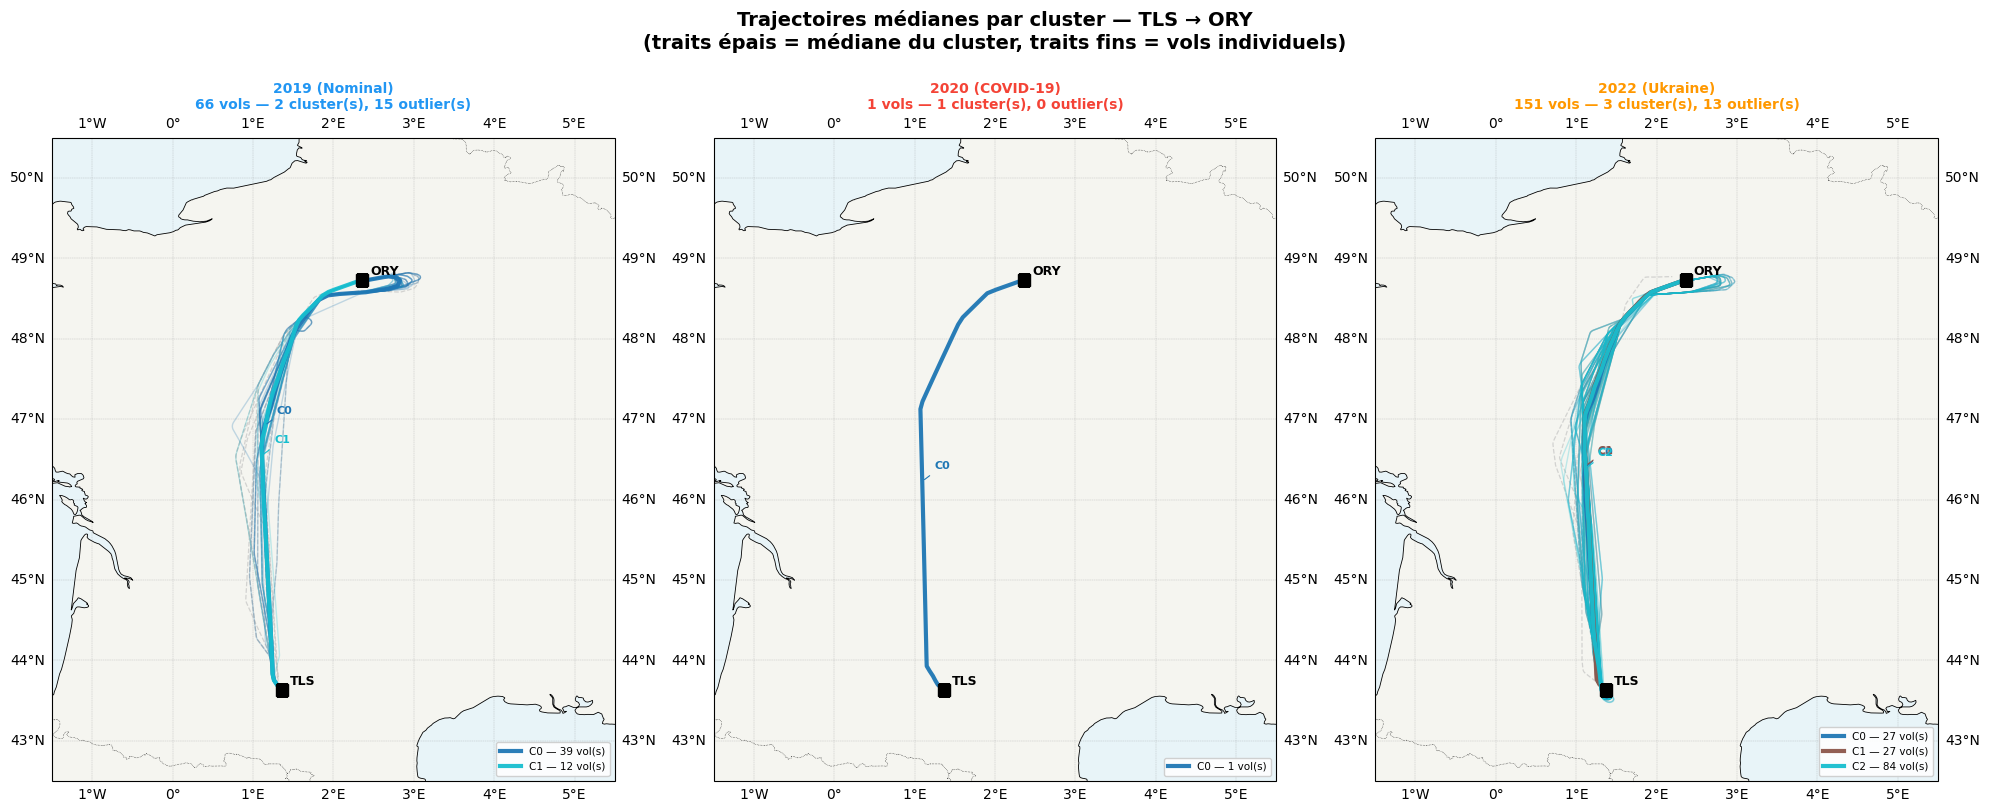

Figure sauvegardée : medianes_clusters_TLS_ORY.png


In [ ]:
def plot_medianes_carte(medianes: dict, figsize: tuple = (20, 8)) -> None:
    labels_periodes = list(medianes.keys())
    n_cols          = len(labels_periodes)
    fig, axes = plt.subplots(1, n_cols, figsize = figsize, subplot_kw = {'projection': ccrs.PlateCarree()})
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(
        f"Trajectoires médianes par cluster — {ORIGIN_IATA} → {DEST_IATA}\n"
        "(traits épais = médiane du cluster, traits fins = vols individuels)",
        fontsize=14, fontweight='bold', y=1.02,
    )
    for ax, label in zip(axes, labels_periodes):
        color = COLORS[label]
        ax.set_extent([-1.5, 5.5, 42.5, 50.5], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,      facecolor='#F5F5F0', zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor='#E8F4F8', zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':', zorder=1)
        ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--', x_inline=False, y_inline=False)

        for apt, name in [(tls_airport, 'TLS'), (ory_airport, 'ORY')]:
            ax.plot(apt.longitude, apt.latitude, 's', color='black', markersize=8, zorder=5, transform=ccrs.PlateCarree())
            ax.text(apt.longitude + 0.1, apt.latitude + 0.07, name, fontsize=9, fontweight='bold', transform=ccrs.PlateCarree(), zorder=6)
        info     = medianes[label]
        clusters = info['clusters']
        outliers = info['outliers']
        cmap           = plt.cm.get_cmap('tab10', max(len(clusters), 1))
        cluster_colors = {c_id: cmap(i) for i, c_id in enumerate(sorted(clusters))}
        for f in outliers['flights']:
            df = f.data.sort_values('timestamp').dropna(subset=['latitude', 'longitude'])
            ax.plot(df['longitude'].values, df['latitude'].values, color='#BBBBBB', linewidth=0.9, alpha=0.6, linestyle='--', transform=ccrs.PlateCarree(), zorder=2)
        for c_id, data_c in sorted(clusters.items()):
            c_color  = cluster_colors[c_id]
            mediane  = data_c['mediane']
            vols     = data_c['flights']
            cs_list  = data_c['callsigns']
            for f in vols:
                df = f.data.sort_values('timestamp').dropna(subset=['latitude', 'longitude'])
                ax.plot(df['longitude'].values, df['latitude'].values, color=c_color, linewidth=1.0, alpha=0.25, transform=ccrs.PlateCarree(), zorder=3)
            med_lats = mediane[0::2]
            med_lons = mediane[1::2]
            ax.plot(med_lons, med_lats, color=c_color, linewidth=3.0, alpha=0.95, transform=ccrs.PlateCarree(), zorder=4, label=f"C{c_id} — {len(vols)} vol(s)")
            mid = len(med_lats) // 2
            ax.annotate(f"C{c_id}", xy=(med_lons[mid], med_lats[mid]), xytext=(med_lons[mid] + 0.15, med_lats[mid] + 0.15), fontsize=8, fontweight='bold', color=c_color, transform=ccrs.PlateCarree(), zorder=6, arrowprops=dict(arrowstyle='-', color=c_color, lw=0.8))

        n_cl  = len(clusters)
        n_out = len(outliers['flights'])
        n_tot = sum(len(d['flights']) for d in clusters.values()) + n_out
        ax.legend(loc='lower right', fontsize=7.5, framealpha=0.9)
        ax.set_title(f"{label}\n{n_tot} vols — {n_cl} cluster(s), {n_out} outlier(s)", fontsize=10, fontweight='bold', color=color)

    plt.tight_layout()
    # plt.savefig("medianes_clusters_TLS_ORY.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure sauvegardée : medianes_clusters_TLS_ORY.png")

plot_medianes_carte(medianes_par_cluster)

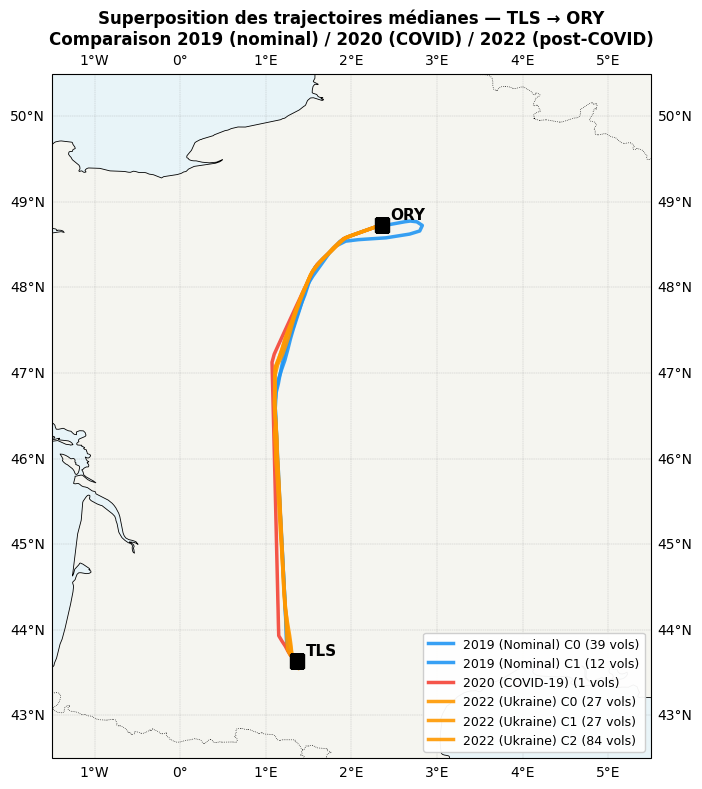

Figure sauvegardée : superposition_medianes_TLS_ORY.png


In [ ]:
def plot_medianes_superposees(medianes: dict, figsize: tuple = (10, 8)) -> None:
    fig, ax = plt.subplots(figsize = figsize, subplot_kw = {'projection': ccrs.PlateCarree()})
    ax.set_extent([-1.5, 5.5, 42.5, 50.5], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#F5F5F0', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#E8F4F8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=':', zorder=1)
    ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--', x_inline=False, y_inline=False)

    for apt, name in [(tls_airport, 'TLS'), (ory_airport, 'ORY')]:
        ax.plot(apt.longitude, apt.latitude, 's', color='black', markersize=10, zorder=5, transform=ccrs.PlateCarree())
        ax.text(apt.longitude + 0.1, apt.latitude + 0.07, name, fontsize=11, fontweight='bold', transform=ccrs.PlateCarree(), zorder=6)
    for label, info in medianes.items():
        color    = COLORS[label]
        clusters = info['clusters']
        for c_id, data_c in sorted(clusters.items()):
            mediane = data_c['mediane']
            n_vols  = len(data_c['flights'])
            suffix  = f" C{c_id}" if len(clusters) > 1 else ""
            med_lats = mediane[0::2]
            med_lons = mediane[1::2]
            ax.plot(med_lons, med_lats, color=color, linewidth=2.5, alpha=0.9, transform=ccrs.PlateCarree(), zorder=4, label=f"{label}{suffix} ({n_vols} vols)")

    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
    ax.set_title(
        f"Superposition des trajectoires médianes — {ORIGIN_IATA} → {DEST_IATA}\n"
        "Comparaison 2019 (nominal) / 2020 (COVID) / 2022 (post-COVID)",
        fontsize=12, fontweight='bold',
    )

    plt.tight_layout()
    # plt.savefig("superposition_medianes_TLS_ORY.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure sauvegardée : superposition_medianes_TLS_ORY.png")

plot_medianes_superposees(medianes_par_cluster)